### [Propensity Score Stratification (PSS)](https://medium.com/causal-inference-methods-models-and-applications/propensity-score-stratification-9c0eea325b32)

> Propensity Score Stratification (PSS) divides the dataset into strata based on propensity scores.

In [1]:
!pip install -qq dowhy networkx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.0/193.0 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 32.3 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore", module="dowhy")
warnings.filterwarnings("ignore")

%autosave 10

Autosaving every 10 seconds


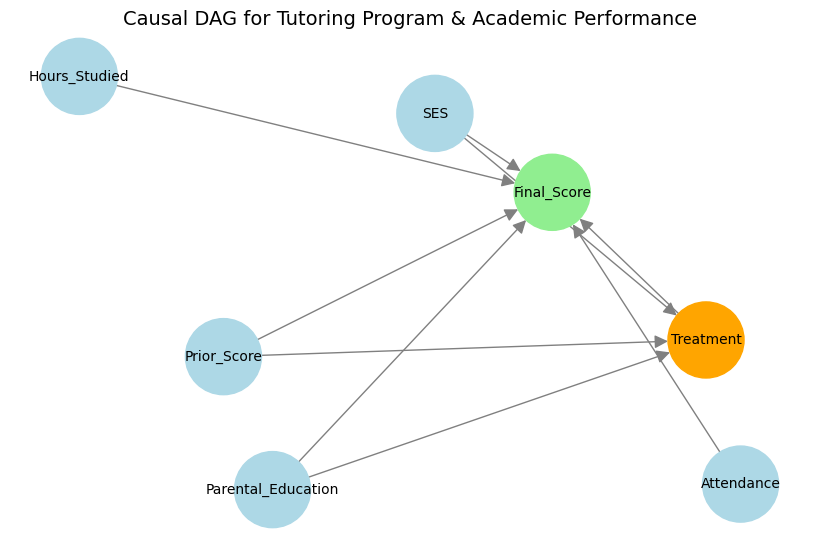

In [3]:
import matplotlib.pyplot as plt
import networkx as nx

# Create DAG
G = nx.DiGraph()

edges = [
    ("SES", "Treatment"),
    ("Parental_Education", "Treatment"),
    ("Prior_Score", "Treatment"),
    ("SES", "Final_Score"),
    ("Parental_Education", "Final_Score"),
    ("Prior_Score", "Final_Score"),
    ("Hours_Studied", "Final_Score"),
    ("Attendance", "Final_Score"),
    ("Treatment", "Final_Score"),
]

G.add_edges_from(edges)

# Node colors: Confounders (blue), Treatment (orange), Outcome (green)
node_colors = {
    "SES": "lightblue",
    "Parental_Education": "lightblue",
    "Prior_Score": "lightblue",
    "Hours_Studied": "lightblue",
    "Attendance": "lightblue",
    "Treatment": "orange",
    "Final_Score": "lightgreen"
}

pos = nx.spring_layout(G, seed=42)

# Plot
plt.figure(figsize=(8, 5))
nx.draw(
    G, pos, with_labels=True,
    node_color=[node_colors[node] for node in G.nodes()],
    node_size=3000, arrowsize=20, edge_color='gray',
    font_size=10,
)
plt.title("Causal DAG for Tutoring Program & Academic Performance", fontsize=14)
plt.show()

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dowhy import CausalModel

np.random.seed(2025)

n = 1500  # large enough for stratification

# Confounders
ses = np.random.choice([0,1,2], size=n, p=[0.35, 0.45, 0.20])
parent_edu = np.random.choice([0,1,2], size=n, p=[0.4, 0.35, 0.25])
confounders = ['ses', 'parent_edu']

# Prior academic score
prior_score_raw = np.random.normal(70, 10, size=n)
prior_score = np.clip(prior_score_raw, 30, 100)

# Hours studied per week
hours_raw = np.random.normal(
    5 + 0.05*(prior_score-70) + 0.8*(parent_edu==2), 2, size=n)
hours_studied = np.clip(hours_raw, 0, 30)

# Attendance
attendance_raw = np.random.normal(
    0.85 + 0.02*(prior_score-70) - 0.04*(ses==0), 0.07, size=n)
attendance = np.clip(attendance_raw, 0.5, 1.0)

# Treatment assignment (logistic model)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

logit = (
    -0.5
    - 0.05*(prior_score - 70)
    + 0.3*(ses == 0)
    - 0.2*(ses == 2)
    - 0.2*(parent_edu == 2))

treatment_prob = sigmoid(logit)
treatment = np.random.binomial(1, treatment_prob, size=n)

# Outcome
true_treatment_effect = 3.0
noise = np.random.normal(0, 4, size=n)
final_score = (
    30
    + 0.45 * prior_score
    + 1.8 * hours_studied
    + 8.0 * attendance
    + 1.5 * (parent_edu == 2)
    - 2.0 * (ses == 0)
    + true_treatment_effect * treatment
    + noise)

# Dataframe
data = pd.DataFrame({
    "ses": ses,
    "parent_edu": parent_edu,
    "prior_score": np.round(prior_score, 2),
    "hours_studied": np.round(hours_studied, 2),
    "attendance": np.round(attendance, 3),
    "treatment": treatment,
    "treatment_prob": np.round(treatment_prob, 3),
    "final_score": np.round(final_score, 2)
})

# Add readable labels
data["ses_label"] = data["ses"].map({0: "low", 1: "medium", 2: "high"})
data["parent_edu_label"] = data["parent_edu"].map({0: "no_college", 1: "some_college", 2: "college_plus"})

data.head()

,ses,parent_edu,prior_score,hours_studied,attendance,treatment,treatment_prob,final_score,ses_label,parent_edu_label
0,0,1,56.26,8.43,0.540,1,0.619,73.99,low,some_college
1,2,0,69.60,8.09,0.825,1,0.336,85.16,high,no_college
2,2,1,77.86,4.02,0.977,0,0.251,81.79,high,some_college
3,1,0,63.89,3.45,0.795,1,0.451,82.92,medium,no_college
4,1,1,82.47,5.58,1.000,0,0.245,86.87,medium,some_college


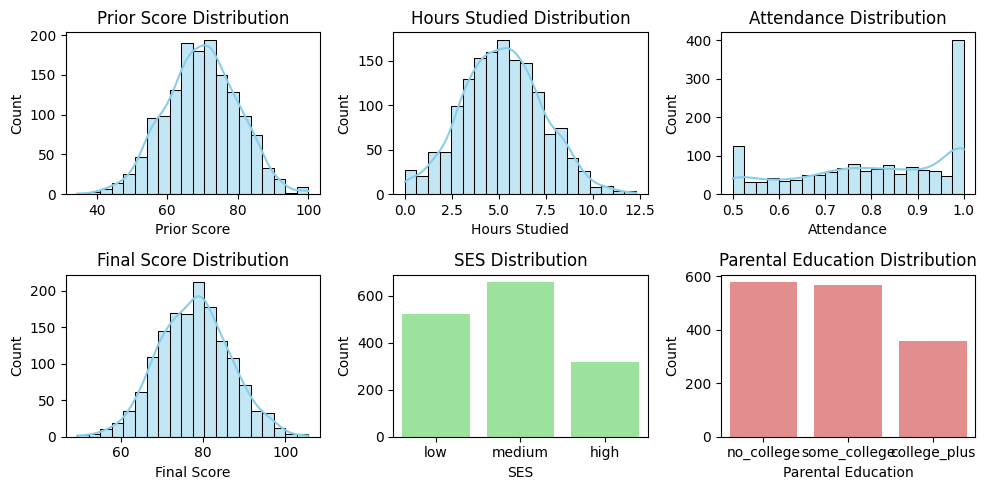

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to plot
numeric_cols = ["prior_score", "hours_studied", "attendance", "final_score"]
categorical_cols = ["ses_label", "parent_edu_label"]

plt.figure(figsize=(10,5))
for i, col in enumerate(numeric_cols):
    plt.subplot(2, 3, i+1)
    sns.histplot(data[col], bins=20, kde=True, color="skyblue")
    plt.title(f"{col.replace('_',' ').title()} Distribution")
    plt.xlabel(col.replace('_',' ').title())
    plt.ylabel("Count")

plt.subplot(2, 3, 5)
sns.countplot(
    data=data,
    x="ses_label",
    order=["low","medium","high"],
    color="lightgreen"
)
plt.title("SES Distribution")
plt.xlabel("SES")
plt.ylabel("Count")

plt.subplot(2, 3, 6)
sns.countplot(
    data=data,
    x="parent_edu_label",
    order=["no_college","some_college","college_plus"],
    color="lightcoral"
)
plt.title("Parental Education Distribution")
plt.xlabel("Parental Education")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [6]:
# Steps 1, 2
model = CausalModel(
    data=data,
    treatment="treatment",
    outcome="final_score",
    common_causes=confounders
)
# Step 3
identified_estimand = model.identify_effect()
# Step 4
ate_estimate = model.estimate_effect(
    identified_estimand,
    method_name="backdoor.propensity_score_stratification",
    target_units="ate"
)

# Bootstrap confidence intervals
ci = ate_estimate.get_confidence_intervals(method="bootstrap", num_simulations=100)
# Print ATE and its 95% confidence interval
print("Estimated ATE:", ate_estimate.value)
print("\n95% Confidence Interval:", ate_estimate.get_confidence_intervals())

# Step 5
# Refutation tests for robustness
ref_placebo = model.refute_estimate(identified_estimand, ate_estimate, method_name="placebo_treatment_refuter")
print("\nPlacebo Test:\n", ref_placebo)

ref_subset = model.refute_estimate(identified_estimand, ate_estimate, method_name="data_subset_refuter")
print("\nSubset Test:\n", ref_subset)

ref_boot = model.refute_estimate(identified_estimand, ate_estimate, method_name="bootstrap_refuter")
print("\nBootstrap Test:\n", ref_boot)

Estimated ATE: 0.42827182889338694

95% Confidence Interval: (np.float64(-0.4193742240835651), np.float64(1.2600333260949148))

Placebo Test:
 Refute: Use a Placebo Treatment
Estimated effect:0.42827182889338694
New effect:0.016863141160047213
p value:0.8799999999999999


Subset Test:
 Refute: Use a subset of data
Estimated effect:0.42827182889338694
New effect:0.40652670054490736
p value:0.96


Bootstrap Test:
 Refute: Bootstrap Sample Dataset
Estimated effect:0.42827182889338694
New effect:0.4281797627508429
p value:0.9



In [7]:
def estimate_effect_subgroup(df, subgroup_condition, target_units="ate"):
    df_sub = df.loc[subgroup_condition].copy()

    # Skip very small subgroups
    treated_count = df_sub['treatment'].sum()
    untreated_count = len(df_sub) - treated_count
    min_per_group = 5
    if treated_count < min_per_group or untreated_count < min_per_group:
        return np.nan, (np.nan, np.nan)

    # Steps 1, 2
    model = CausalModel(
        data=df_sub,
        treatment="treatment",
        outcome="final_score",
        common_causes=confounders
    )

    identified_estimand = model.identify_effect()

    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.propensity_score_stratification",
        method_params={"num_strata": 2, "clipping_threshold": min_per_group},
        target_units=target_units
    )

    # Bootstrap confidence intervals
    ci = estimate.get_confidence_intervals(method="bootstrap", num_simulations=100)
    return estimate.value, ci

ses_labels = ["low", "medium", "high"]
parent_labels = ["no_college", "some_college", "college_plus"]

results = []
for ses in ses_labels:
    for parent in parent_labels:
        cond = (data["ses_label"] == ses) & (data["parent_edu_label"] == parent)

        ate, ate_ci = estimate_effect_subgroup(data, cond, target_units="ate")
        att, att_ci = estimate_effect_subgroup(data, cond, target_units="att")

        results.append({
            "SES": ses,
            "Parental_Education": parent,
            "CATE_Group": f"{ses}-{parent}",  # Explicit CATE label
            "ATE": ate,
            "ATE_CI_Lower": ate_ci[0],
            "ATE_CI_Upper": ate_ci[1],
            "ATT": att,
            "ATT_CI_Lower": att_ci[0],
            "ATT_CI_Upper": att_ci[1]
        })

results_df = pd.DataFrame(results)
results_df

,SES,Parental_Education,CATE_Group,ATE,ATE_CI_Lower,ATE_CI_Upper,ATT,ATT_CI_Lower,ATT_CI_Upper
0,low,no_college,low-no_college,-0.532456,-2.837122,1.528325,-0.532456,-3.615283,1.571135
1,low,some_college,low-some_college,-0.178156,-2.280411,2.288480,-0.178156,-2.386306,1.602613
2,low,college_plus,low-college_plus,2.343278,-1.363342,6.092504,2.343278,-0.878016,5.446068
3,medium,no_college,medium-no_college,0.902768,-1.292860,3.431322,0.902768,-1.189994,3.677009
4,medium,some_college,medium-some_college,-0.016329,-1.742865,2.040589,-0.016329,-1.773652,2.219177
5,medium,college_plus,medium-college_plus,-0.513349,-2.918011,2.234284,-0.513349,-3.375616,2.403752
6,high,no_college,high-no_college,3.793115,0.640667,6.529633,3.793115,0.341170,6.338771
7,high,some_college,high-some_college,-2.619871,-5.385746,0.265115,-2.619871,-5.210137,-0.136811
8,high,college_plus,high-college_plus,2.933522,-0.314887,6.358635,2.933522,0.434158,6.187043


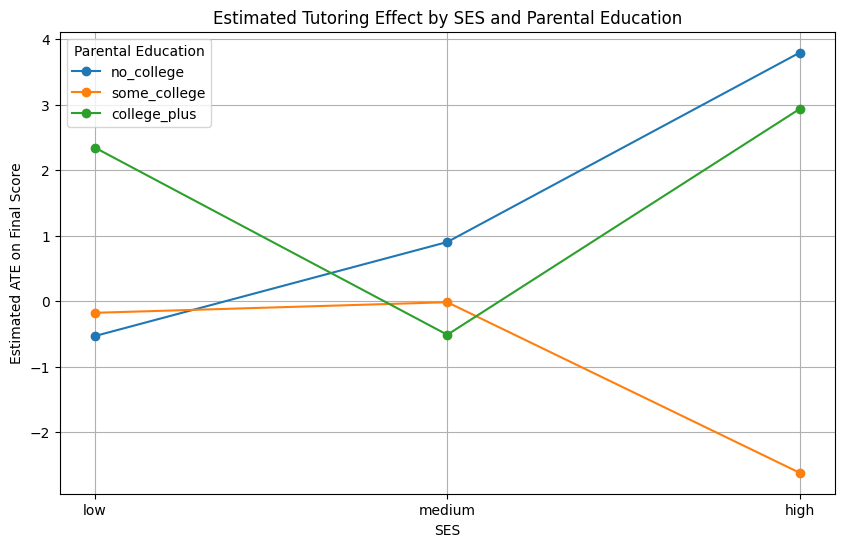

In [8]:
plt.figure(figsize=(10,6))

for parent in parent_labels:
    subset = results_df[results_df["Parental_Education"]==parent]
    plt.plot(subset["SES"], subset["ATE"], marker='o', label=parent)

plt.xlabel("SES")
plt.ylabel("Estimated ATE on Final Score")
plt.title("Estimated Tutoring Effect by SES and Parental Education")
plt.legend(title="Parental Education")
plt.grid(True)
plt.show()

In [9]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Select confounders
confounders = ["prior_score", "ses", "parent_edu"]

# One-hot encode ses and parent_edu
data_encoded = pd.get_dummies(data[confounders], columns=["ses", "parent_edu"], drop_first=True)

# Propensity score
ps_model = LogisticRegression()
ps_model.fit(data_encoded, data["treatment"])

# Add propensity scores to original dataframe
data["propensity_score"] = ps_model.predict_proba(data_encoded)[:,1]

# Into strata
data["ps_stratum"] = pd.qcut(data["propensity_score"], q=10, labels=False)
data.head()

,ses,parent_edu,prior_score,hours_studied,attendance,treatment,treatment_prob,final_score,ses_label,parent_edu_label,propensity_score,strata,dbar,d_y,dbar_y,ps_stratum
0,0,1,56.26,8.43,0.540,1,0.619,73.99,low,some_college,0.574860,14.0,0,73.99,0.00,9
1,2,0,69.60,8.09,0.825,1,0.336,85.16,high,no_college,0.290229,3.0,0,85.16,0.00,2
2,2,1,77.86,4.02,0.977,0,0.251,81.79,high,some_college,0.257240,2.0,1,0.00,81.79,1
3,1,0,63.89,3.45,0.795,1,0.451,82.92,medium,no_college,0.429020,10.0,0,82.92,0.00,6
4,1,1,82.47,5.58,1.000,0,0.245,86.87,medium,some_college,0.297078,7.0,1,0.00,86.87,2


In [10]:
strata_results = []

for s in sorted(data["ps_stratum"].unique()):
    subset = data[data["ps_stratum"] == s]
    treated_mean = subset[subset["treatment"]==1]["final_score"].mean()
    control_mean = subset[subset["treatment"]==0]["final_score"].mean()
    treated_count = len(subset[subset["treatment"]==1])
    control_count = len(subset[subset["treatment"]==0])
    ate = treated_mean - control_mean
    strata_results.append({
        "Stratum": s,
        "Treated_Mean": treated_mean,
        "Control_Mean": control_mean,
        "Treated_Count": treated_count,
        "Control_Count": control_count,
        "ATE": ate
    })

strata_df = pd.DataFrame(strata_results)
strata_df

,Stratum,Treated_Mean,Control_Mean,Treated_Count,Control_Count,ATE
0,0,88.516667,86.913821,27,123,1.602846
1,1,86.610455,83.277925,44,106,3.332530
2,2,83.845918,80.755743,49,101,3.090176
3,3,82.324894,78.916311,47,103,3.408583
4,4,79.822200,78.388200,50,100,1.434000
5,5,79.826842,76.603656,57,93,3.223186
6,6,77.411774,74.141705,62,88,3.270070
7,7,76.060986,72.417215,71,79,3.643771
8,8,73.299367,69.080563,79,71,4.218804
9,9,67.712143,65.430152,84,66,2.281991


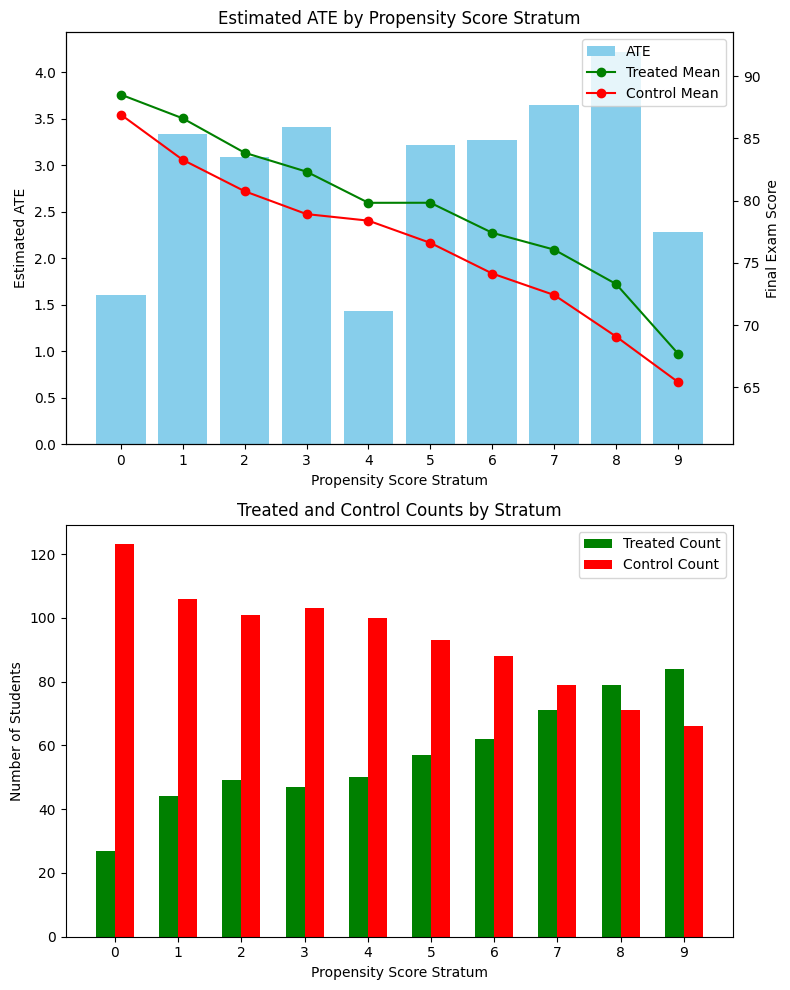

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8,10))

# Plot ATE bars
ax1.bar(strata_df["Stratum"], strata_df["ATE"], color="skyblue", label="ATE")
ax1.set_xlabel("Propensity Score Stratum")
ax1.set_ylabel("Estimated ATE")
ax1.set_xticks(strata_df["Stratum"])

# Secondary axis for Treated/Control means
ax1b = ax1.twinx()
ax1b.plot(strata_df["Stratum"], strata_df["Treated_Mean"], marker='o', color='green', label='Treated Mean')
ax1b.plot(strata_df["Stratum"], strata_df["Control_Mean"], marker='o', color='red', label='Control Mean')
ax1b.set_ylabel("Final Exam Score")
ax1b.set_ylim(min(strata_df["Control_Mean"])-5, max(strata_df["Treated_Mean"])+5)

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1b.get_legend_handles_labels()
ax1b.legend(lines_1 + lines_2, labels_1 + labels_2, loc="upper right")

ax1.set_title("Estimated ATE by Propensity Score Stratum")

# plot: Treated & Control Counts
ax2.bar(strata_df["Stratum"]-0.15, strata_df["Treated_Count"], width=0.3, color='green', label='Treated Count')
ax2.bar(strata_df["Stratum"]+0.15, strata_df["Control_Count"], width=0.3, color='red', label='Control Count')
ax2.set_xlabel("Propensity Score Stratum")
ax2.set_ylabel("Number of Students")
ax2.set_xticks(strata_df["Stratum"])
ax2.legend()
ax2.set_title("Treated and Control Counts by Stratum")

plt.tight_layout()
plt.show()